## i. Perkenalan

Nama : Kesyia L Patty

Batch : FTDS-037-HCK

Dataset : P1G6_Kesyia.csv

Objective : Melakukan Customer Segmentation dari data kartu kredit selama 6 bulan terakhir, menggunakan algoritma K-Means dan dimensionality reduction dengan PCA.

## ii. Query SQL

SELECT *
FROM `ftds-hacktiv8-project.phase1_ftds_037_hck.credit-card-information`
where MOD(CAST(CUST_ID AS INT64),2)!= 0
 

## iii. Import Libraries

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score,silhouette_samples
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## iv. Data Loading

In [121]:
df = pd.read_csv('P1G6_Kesyia.csv')
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1209,210.993146,0.818182,90.51,90.51,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,6500.0,1240.766161,230.983088,0.0,12
1,4861,163.335524,0.545455,460.95,460.95,0.0,0.0,0.083333,0.083333,0.0,0.0,0,2,1500.0,162.939482,77.604225,0.0,12
2,4955,1096.949604,1.000000,227.55,227.55,0.0,0.0,0.083333,0.083333,0.0,0.0,0,2,2500.0,397.836763,352.173130,0.0,12
3,5359,1.869435,0.454545,0.24,0.24,0.0,0.0,0.083333,0.083333,0.0,0.0,0,0,3000.0,150.381107,53.294711,0.0,12
4,6333,7.215615,0.272727,54.45,54.45,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,2000.0,160.130111,205.168209,0.0,12
5,5183,1523.552696,1.000000,1810.00,1810.00,0.0,0.0,0.100000,0.100000,0.0,0.0,0,1,1850.0,368.561315,390.858281,0.0,10
6,6041,36.607995,0.545455,224.40,224.40,0.0,0.0,0.166667,0.166667,0.0,0.0,0,2,2100.0,372.093413,151.080030,0.0,12
7,7149,15.236618,0.272727,161.50,161.50,0.0,0.0,0.166667,0.166667,0.0,0.0,0,1,3000.0,912.737392,114.337421,0.0,12
8,903,15.810927,0.363636,246.29,246.29,0.0,0.0,0.181818,0.181818,0.0,0.0,0,4,500.0,149.886496,23.323100,0.0,11
9,6805,210.870503,1.000000,664.05,664.05,0.0,0.0,0.200000,0.200000,0.0,0.0,0,5,7500.0,728.192680,140.348508,0.0,10


In [122]:
df.tail(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4465,7745,1821.040307,1.000000,166.38,116.38,50.00,1682.602932,0.400000,0.200000,0.2,0.400000,13,5,5000.0,3388.896555,520.445922,0.000000,10
4466,4467,1457.381936,1.000000,0.00,0.00,0.00,236.725014,0.000000,0.000000,0.0,0.416667,7,0,1500.0,536.361045,508.611551,0.000000,12
4467,5993,1527.826042,1.000000,3191.00,3191.00,0.00,2035.662918,0.083333,0.083333,0.0,0.416667,17,3,4950.0,5393.198816,436.082971,0.083333,12
4468,3765,975.946428,1.000000,1572.42,783.03,789.39,1910.395479,1.000000,0.583333,1.0,0.416667,11,34,1700.0,4024.595117,559.828935,0.166667,12
4469,1017,4653.854929,1.000000,360.00,360.00,0.00,4267.213570,0.500000,0.500000,0.0,0.500000,17,6,5000.0,2676.029302,5204.152199,0.000000,12
4470,673,5471.186593,0.777778,0.00,0.00,0.00,8411.998221,0.000000,0.000000,0.0,0.555556,10,0,9000.0,1281.454609,1401.967646,0.000000,9
4471,2531,5314.739322,1.000000,0.00,0.00,0.00,3596.096650,0.000000,0.000000,0.0,0.583333,20,0,8000.0,1582.770873,2632.897525,0.000000,12
4472,3549,2336.985188,1.000000,190.56,190.56,0.00,4066.421468,0.166667,0.166667,0.0,0.583333,10,4,3500.0,8319.645575,1423.865598,0.250000,12
4473,6239,1283.280303,0.777778,0.00,0.00,0.00,5790.596470,0.000000,0.000000,0.0,0.666667,17,0,3000.0,4073.172497,270.257736,0.000000,9
4474,8127,3857.562230,1.000000,0.00,0.00,0.00,2127.213754,0.000000,0.000000,0.0,1.142857,26,0,5000.0,617.508991,538.396872,0.000000,7


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           4475 non-null   int64  
 1   BALANCE                           4475 non-null   float64
 2   BALANCE_FREQUENCY                 4475 non-null   float64
 3   PURCHASES                         4475 non-null   float64
 4   ONEOFF_PURCHASES                  4475 non-null   float64
 5   INSTALLMENTS_PURCHASES            4475 non-null   float64
 6   CASH_ADVANCE                      4475 non-null   float64
 7   PURCHASES_FREQUENCY               4475 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        4475 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  4475 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            4475 non-null   float64
 11  CASH_ADVANCE_TRX                  4475 non-null   int64  
 12  PURCHA

In [124]:
# tidak ada duplikasi data
df.duplicated().sum()

0

## v. Exploratory Data Analysis (EDA)
1. Apakah terdapat pola antara pengaruh TENURE dengan variabel PURCHASES, BALANCE, dan PAYMENTS ?Buatlah visualisasi!
2. Apakah nasabah dengan CREDIT_LIMIT yang tinggi cenderung lebih sering melakukan pembelian ? Lakukanlah analisis untuk mengetahui bagaimana CREDIT_LIMIT mempengaruhi frekuensi pembelian (PURCHASES_FREQUENCY). Buatlah visualisasi!


NOTE: 

untuk EDA di sini saya menggunakan data copyan dari data df yang nantinya akan saya pakai dalam modeling, saya memisahkannya supaya saya bisa leluasa untuk handling missing value/outlier tanpa mengganggu data tersebut saat di modeling nanti, supaya meminimalisir data leakage jika saya sudah menghandle-nya sebelum feature engineering

### 1) Identifikasi dan Handling missing value untuk EDA

In [125]:
# Untuk EDA saya menggunakan data yang terpisah dari data untuk modeling yaitu df_copy
df_copy = df.copy()
df_copy.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          0
PAYMENTS                              0
MINIMUM_PAYMENTS                    155
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [126]:
missing_data = df_copy.isnull().sum()/len(df_copy)*100
print(missing_data.sort_values(ascending=False))

MINIMUM_PAYMENTS                    3.463687
CUST_ID                             0.000000
BALANCE                             0.000000
PRC_FULL_PAYMENT                    0.000000
PAYMENTS                            0.000000
CREDIT_LIMIT                        0.000000
PURCHASES_TRX                       0.000000
CASH_ADVANCE_TRX                    0.000000
CASH_ADVANCE_FREQUENCY              0.000000
PURCHASES_INSTALLMENTS_FREQUENCY    0.000000
ONEOFF_PURCHASES_FREQUENCY          0.000000
PURCHASES_FREQUENCY                 0.000000
CASH_ADVANCE                        0.000000
INSTALLMENTS_PURCHASES              0.000000
ONEOFF_PURCHASES                    0.000000
PURCHASES                           0.000000
BALANCE_FREQUENCY                   0.000000
TENURE                              0.000000
dtype: float64


In [127]:
# OUTLIER MINIMUM_PAYMENTS
Q1 = df_copy['MINIMUM_PAYMENTS'].quantile(0.25)
Q3 = df_copy['MINIMUM_PAYMENTS'].quantile(0.75)
IQR = Q3 - Q1
# Menghitung batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengambil data normal (Inliers)
is_outlier = (df_copy['MINIMUM_PAYMENTS'] < lower_bound) | (df_copy['MINIMUM_PAYMENTS'] > upper_bound)

# 2. Hitung jumlah baris yang outlier
jumlah_outlier = is_outlier.sum()

# 3. Hitung persentase terhadap total data
total_data = len(df_copy)
persentase_outlier = (jumlah_outlier / total_data) * 100
# Tampilkan hasil
print(f"Jumlah Outlier: {jumlah_outlier}")
print(f"Persentase Outlier: {persentase_outlier:.2f}%")

Jumlah Outlier: 441
Persentase Outlier: 9.85%


#### Mengisi data NaN dengan Median

In [ ]:
median_val = df_copy['MINIMUM_PAYMENTS'].median()
df_copy['MINIMUM_PAYMENTS'] = df_copy['MINIMUM_PAYMENTS'].fillna(median_val)

In [129]:
df_copy.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

INSIGHT :

Penanganan Missing Values pada MINIMUM_PAYMENTS dilakukan dengan metode Imputasi Median. Hal ini didasarkan pada dua temuan kritis: Pertama, terdapat outlier sebesar 9.85% yang menunjukkan adanya segelintir nasabah dengan nilai pembayaran sangat ekstrem. Kedua, nilai Skewness yang sangat tinggi (14.67) mengonfirmasi distribusi data yang menceng ke kanan (positive skew), di mana mayoritas nasabah melakukan pembayaran kecil namun rata-rata data tertarik oleh nilai ekstrem. Penggunaan Median dipilih karena lebih robust (tahan) terhadap pengaruh pencilan dibanding Mean, sehingga menjaga integritas distribusi data asli.


### 2) Identifikasi dan Handling Outliers untuk seluruh kolom data

Distribusi Data

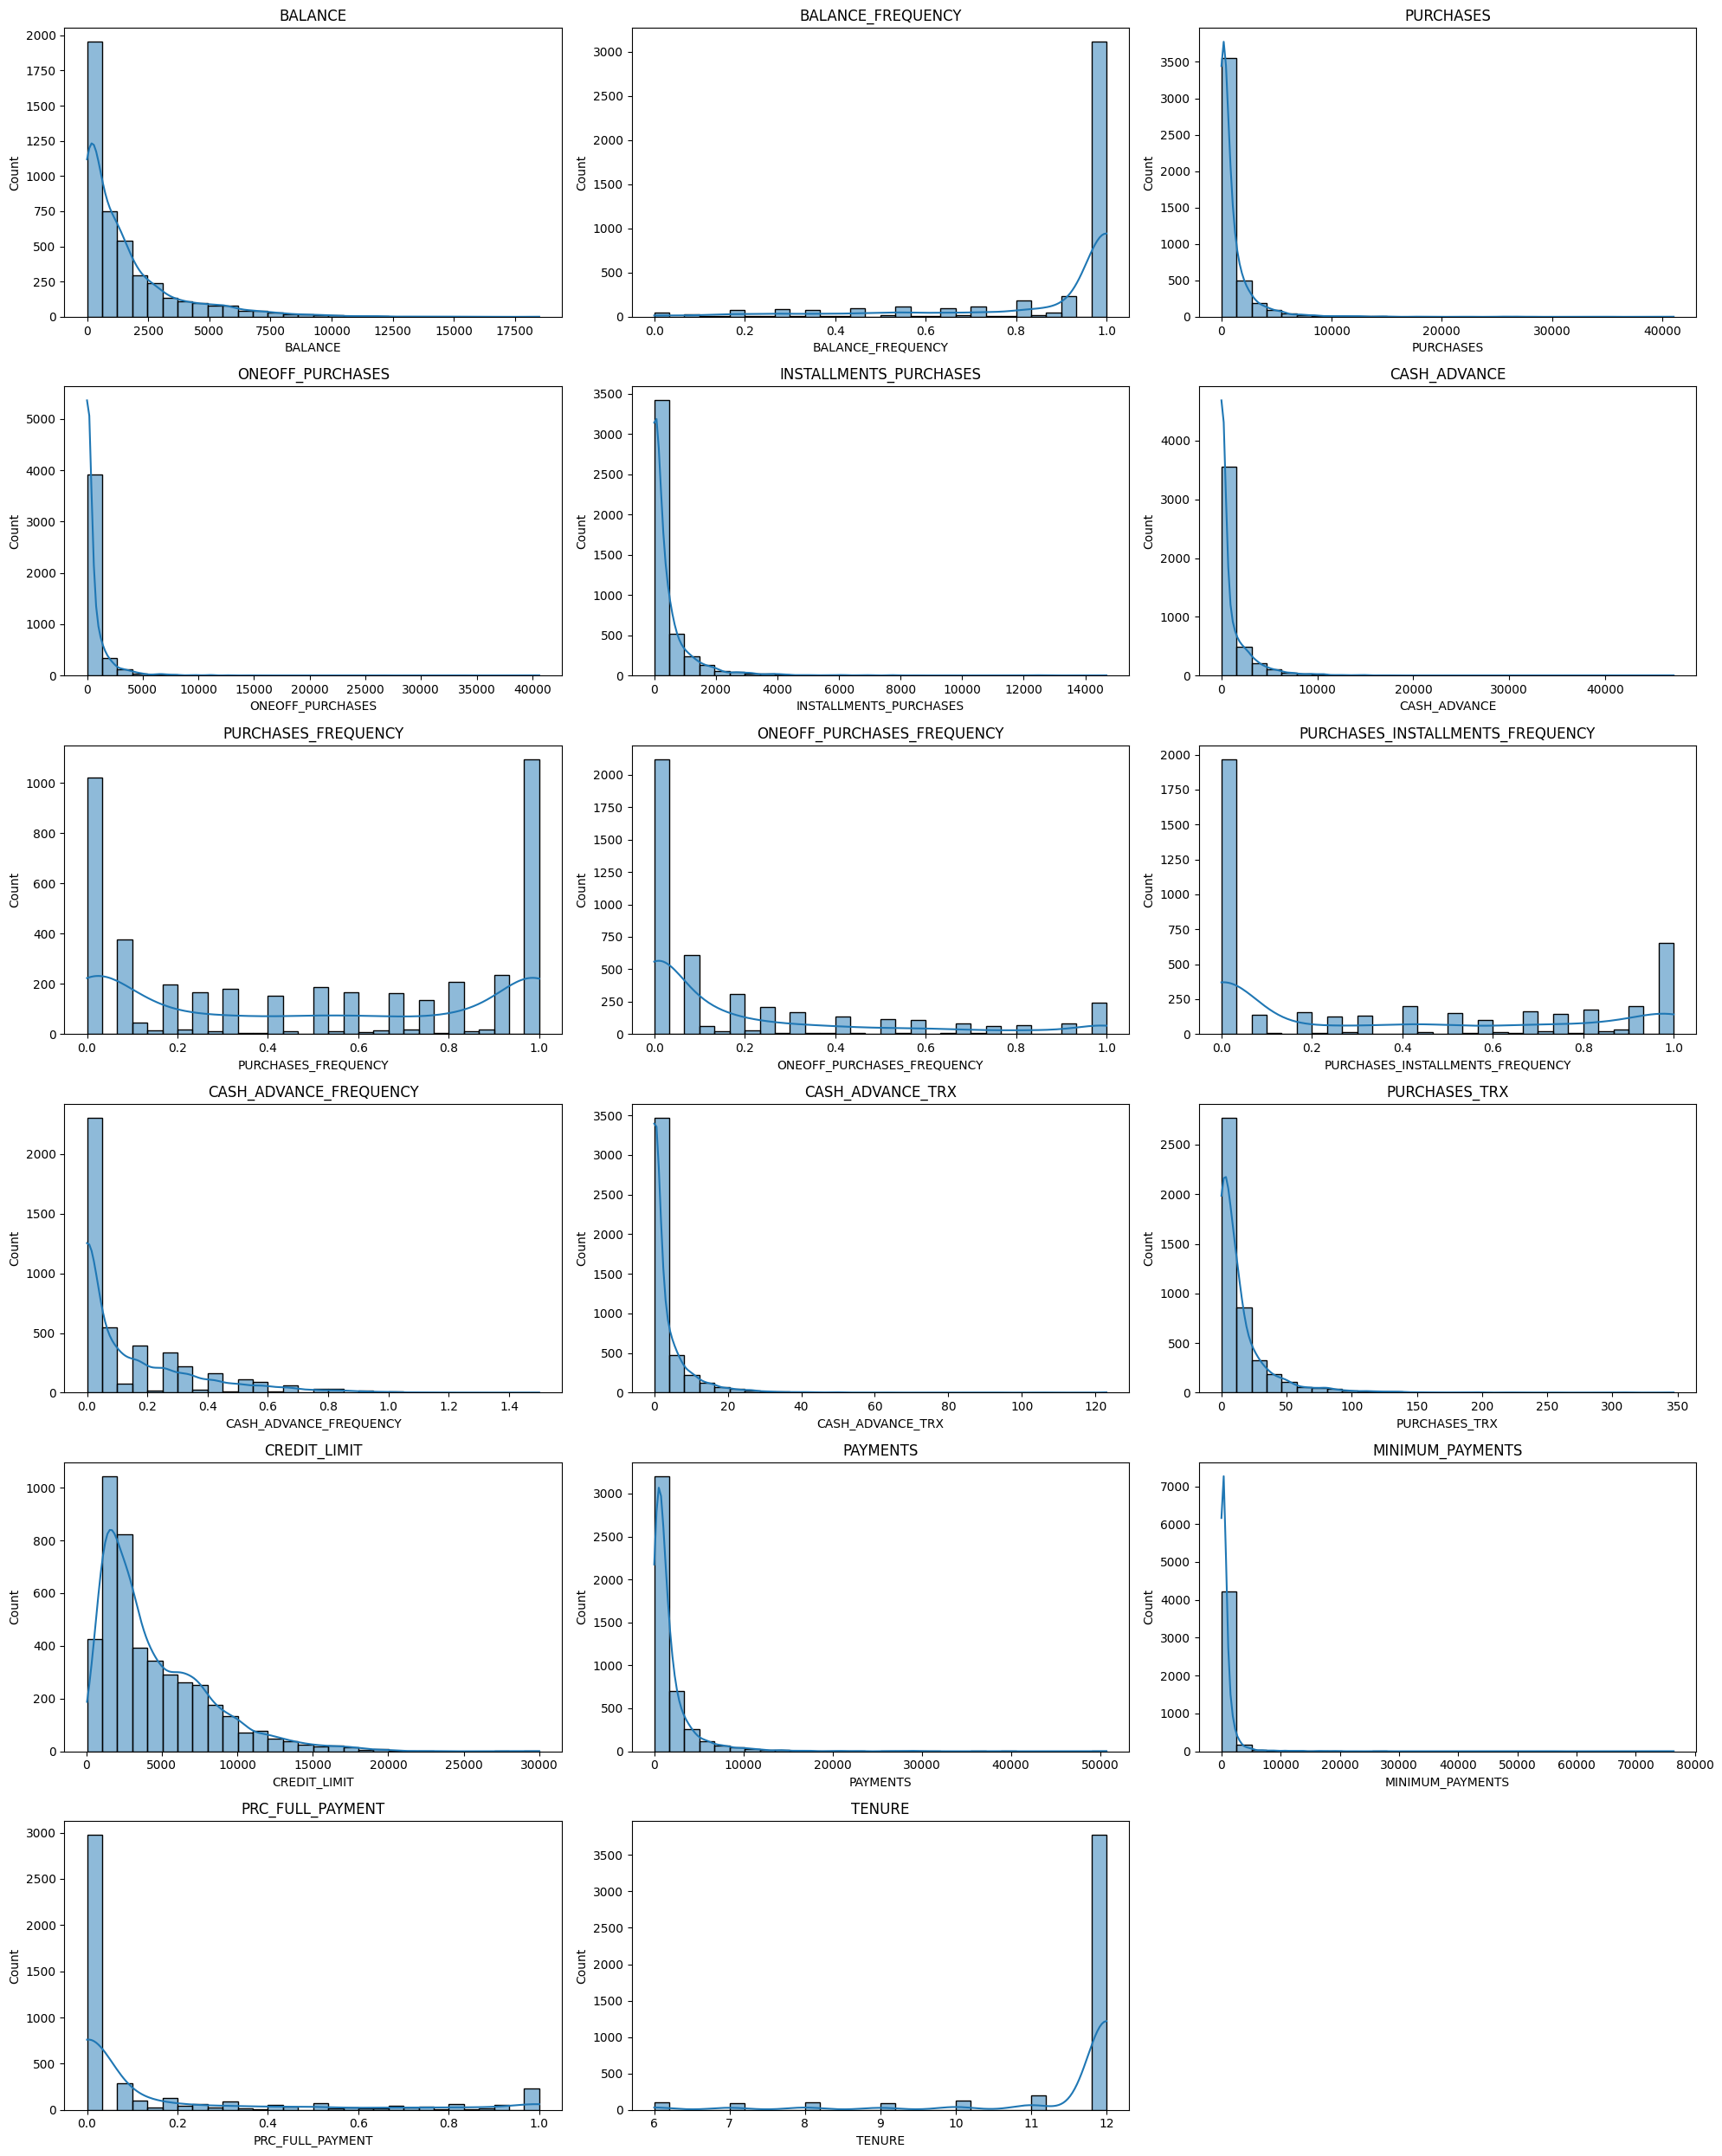

In [130]:
# Ambil kolom numerik
numeric_cols = df_copy.select_dtypes(include=['int64','float64']).columns

# Exclude ID
numeric_cols = [col for col in numeric_cols if col != 'CUST_ID']

plt.figure(figsize=(20, 25))

for i, col in enumerate(numeric_cols):
    plt.subplot(6, 3, i+1)
    sns.histplot(df_copy[col].dropna(), bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

#### Insight : 

Dilihat dari pola grafiknya, data ini menunjukkan ketimpangan yang cukup tajam atau memiliki skewness yang sangat kuat di hampir semua variabel transaksi. Sebagian besar nasabah tercatat hanya melakukan pengeluaran kecil, namun ada segelintir nasabah "ekstrem" di sisi kanan yang angka belanjanya sangat tinggi, sehingga ekor distribusinya tertarik memanjang. Di sisi lain, variabel seperti Tenure dan Balance Frequency justru menumpuk di sisi kanan, yang menandakan mayoritas pengguna dalam dataset ini adalah nasabah setia dan aktif. Mengingat distribusinya tidak membentuk kurva lonceng yang simetris, data ini nanti akan diproses terlebih dahulu dari missing value dan outlier nanti agar hasil analisis atau pengelompokan (clustering) nantinya tidak bias oleh nilai-nilai tersebut.

In [131]:
df_copy['MINIMUM_PAYMENTS'].skew().round(3)

14.913

In [132]:
# Buat salinan df
df_copy = df.copy()

# Temukan outliers pada df_copy
numerical_cols = df_copy.select_dtypes(include=['int64','float64'])
numerical_cols = [col for col in numerical_cols if df_copy[col].nunique() > 1]  

outlier_summary = []

for col in numerical_cols:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    # Filter menggunakan df_copy
    outliers = df_copy[(df_copy[col] < Q1 - 1.5*IQR) | (df_copy[col] > Q3 + 1.5*IQR)]
    count = len(outliers)
    pct = (count / len(df_copy)) * 100
    outlier_summary.append({'Feature': col, 'Outliers Count': count, 'Outliers %': pct})

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outliers %', ascending=False)
outlier_df


,Feature,Outliers Count,Outliers %
16,PRC_FULL_PAYMENT,797,17.810056
2,BALANCE_FREQUENCY,748,16.715084
17,TENURE,698,15.597765
8,ONEOFF_PURCHASES_FREQUENCY,557,12.446927
4,ONEOFF_PURCHASES,523,11.687151
6,CASH_ADVANCE,504,11.262570
5,INSTALLMENTS_PURCHASES,442,9.877095
15,MINIMUM_PAYMENTS,441,9.854749
3,PURCHASES,424,9.474860
14,PAYMENTS,414,9.251397


INSIGHT : 

Berdasarkan identifikasi di atas, ditemukan bahwa fitur-fitur seperti PRC_FULL_PAYMENT, BALANCE_FREQUENCY, dan TENURE memiliki persentase outlier di atas 15%. Secara statistik, data ini memiliki variansi yang tinggi. Namun, untuk tahap EDA, data outliers ini tidak dilakukan handling apap-apa (tetap dipertahankan).
Hal ini dikarenakan outlier tersebut bukan merupakan kesalahan input (data entry error), melainkan representasi dari segmen nasabah spesifik (seperti nasabah dengan perilaku pelunasan penuh atau penggunaan limit ekstrem). Penghapusan atau pengubahan data ini pada tahap awal dapat menyebabkan hilangnya informasi berharga mengenai segmentasi nasabah-nasabah tsb.

In [133]:
# cek ringkaasan statistik
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
CUST_ID,4475.0,4475.000000,2583.931114,1.000000,2238.000000,4475.000000,6712.000000,8949.00000
BALANCE,4475.0,1563.205717,2072.045789,0.000000,124.432849,871.355430,2047.570799,18495.55855
BALANCE_FREQUENCY,4475.0,0.876933,0.238222,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,4475.0,1003.251343,2060.034730,0.000000,39.560000,360.000000,1102.420000,41050.40000
ONEOFF_PURCHASES,4475.0,596.369893,1653.425984,0.000000,0.000000,45.650000,575.220000,40624.06000
INSTALLMENTS_PURCHASES,4475.0,407.110215,880.799744,0.000000,0.000000,88.620000,455.885000,14686.10000
CASH_ADVANCE,4475.0,984.288554,2060.448056,0.000000,0.000000,0.000000,1138.887754,47137.21176
PURCHASES_FREQUENCY,4475.0,0.490579,0.402907,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,4475.0,0.202301,0.298203,0.000000,0.000000,0.083333,0.250000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,4475.0,0.363886,0.397603,0.000000,0.000000,0.166667,0.750000,1.00000


#### 1. Analysis pengaruh TENURE dengan variabel PURCHASES, BALANCE, dan PAYMENTS

##### Cek Distribusi 

In [134]:
columns = ['TENURE','PURCHASES','BALANCE','PAYMENTS']
for i in range(len(columns)):
    print(f'{columns[i]} skewness : {df_copy[columns[i]].skew().round(3)}')

TENURE skewness : -2.954
PURCHASES skewness : 7.072
BALANCE skewness : 2.329
PAYMENTS skewness : 5.748


#### HASIL UJI KORELASI DENGAN SPEARMAN

Berdasarkan hasil nilai skewness di atas untuk metode uji korelasi yang dipakai adalah spearman karena sebaran data tidak normal

In [135]:
# 1. Pilih kolom yang ingin diuji korelasi dengan TENURE
kolom_pilihan = ['TENURE', 'PURCHASES', 'BALANCE', 'PAYMENTS']

# 2. Hitung korelasi Spearman untuk semua kolom tersebut
matriks_korelasi = df_copy[kolom_pilihan].corr(method='spearman')

# 3. Tampilkan hasil berupa tabel angka
print("Matriks Korelasi Spearman:")
print(matriks_korelasi)

Matriks Korelasi Spearman:
             TENURE  PURCHASES   BALANCE  PAYMENTS
TENURE     1.000000   0.126401  0.061795  0.198596
PURCHASES  0.126401   1.000000  0.005338  0.392176
BALANCE    0.061795   0.005338  1.000000  0.450907
PAYMENTS   0.198596   0.392176  0.450907  1.000000


#### Visualisasi Korelasi TENURE dengan PURCHASES, BALANCE, dan PAYMENTS 

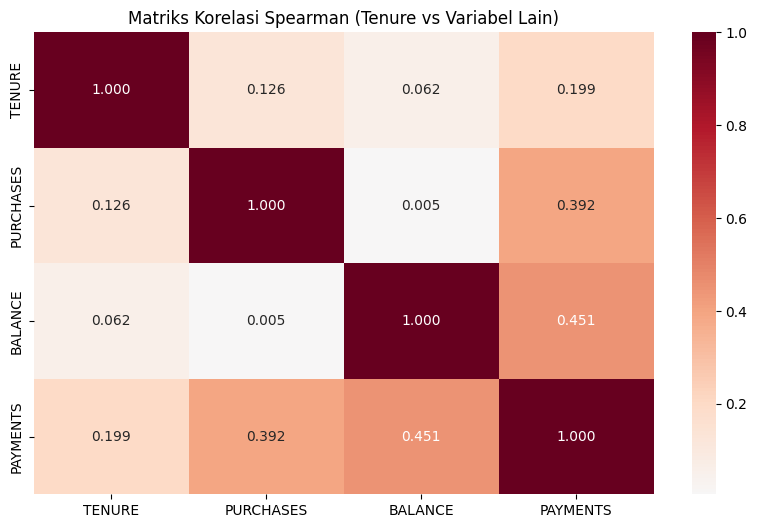

In [136]:
# 4. Tampilkan dalam bentuk Heatmap agar lebih mudah dibaca
plt.figure(figsize=(10, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='RdBu_r', center=0, fmt='.3f')
plt.title('Matriks Korelasi Spearman (Tenure vs Variabel Lain)')
plt.show()


#### INSIGHT :

Dari hasil uji korelasi yang di atas :
- TENURE & PAYMENTS (0.199): Hubungan sangat lemah.

- TENURE & PURCHASES (0.126): Hubungan sangat lemah.

- TENURE & BALANCE (0.062): Hampir tidak ada hubungan.


#### 2. Analisis untuk mengetahui bagaimana CREDIT_LIMIT mempengaruhi frekuensi pembelian 

#### Cek Distribusi dengan skewness

In [137]:
columns = ['CREDIT_LIMIT','PURCHASES_FREQUENCY']
for i in range(len(columns)):
    print(f'{columns[i]} skewness : {df_copy[columns[i]].skew().round(3)}')

CREDIT_LIMIT skewness : 1.499
PURCHASES_FREQUENCY skewness : 0.059


#### HASIL UJI KORELASI DENGAN SPEARMAN

Berdasarkan hasil nilai skewness di atas untuk metode uji korelasi yang dipakai adalah spearman karena sebaran data tidak normal

In [138]:
korelasi = df_copy['CREDIT_LIMIT'].corr(df_copy['PURCHASES_FREQUENCY'], method='spearman')
print(f"Korelasi Spearman: {korelasi:.3f}")


Korelasi Spearman: 0.085


#### Visualisasi Korelasi CREDIT_LIMIT dan PURCHASES_FREQUENCY

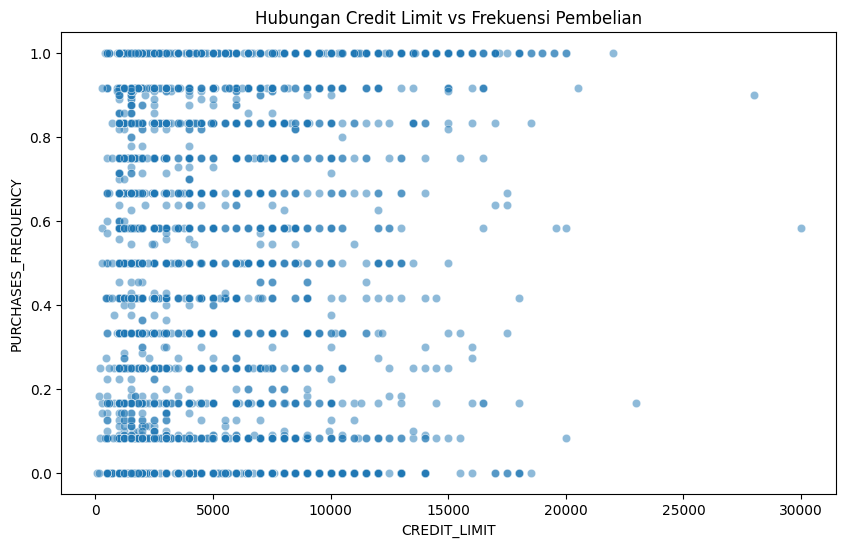

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CREDIT_LIMIT', y='PURCHASES_FREQUENCY', data=df_copy, alpha=0.5)
plt.title('Hubungan Credit Limit vs Frekuensi Pembelian')
plt.show()


#### Insight 

Berdasarkan hasil di atas dapat dilihat: 
- CREDIT_LIMIT & PURCHASES_FREQUENCY (0.085): Hubungan sangat lemah / hampir tidak ada, besarnya limit kredit tidak menjamin nasabah akan lebih sering melakukan pembelian; nasabah dengan limit rendah hingga tinggi menunjukkan sebaran frekuensi belanja yang serupa.

- Visualisasi: Scatter plot menunjukkan titik data yang tersebar merata tanpa pola diagonal, mengonfirmasi bahwa kapasitas kredit bukan merupakan pendorong utama frekuensi transaksi nasabah.



## vi. Feature Engineering

- handle missing values
- handle outlier
- pipeline (missing value/null,split,scaling,encoding etc)

### Handle missing values

In [140]:
df.isnull().sum() # >> MINIMUM_PAYMENTS : 155 NAN
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [141]:
df = df.drop('CUST_ID', axis=1) # drop kolom yang tidak berpengaruh

### Handle outlier 
>> Untuk kasus ini karena ditujukan untuk segmentasi jadi semua jenis transaksi nasabah bahkan yang outlier akan saya pertahankan oleh karena itu saya akan menggunakan log transform untuk membuat outlier tetap ada tapi jaraknya 'masuk akal'

In [142]:
# Temukan outliers pada df
numerical_cols = df.select_dtypes(include=['int64','float64'])
numerical_cols = [col for col in numerical_cols if df[col].nunique() > 1]  

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Filter menggunakan df_copy
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    count = len(outliers)
    pct = (count / len(df)) * 100
    outlier_summary.append({'Feature': col, 'Outliers Count': count, 'Outliers %': pct})

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outliers %', ascending=False)
outlier_df


,Feature,Outliers Count,Outliers %
15,PRC_FULL_PAYMENT,797,17.810056
1,BALANCE_FREQUENCY,748,16.715084
16,TENURE,698,15.597765
7,ONEOFF_PURCHASES_FREQUENCY,557,12.446927
3,ONEOFF_PURCHASES,523,11.687151
5,CASH_ADVANCE,504,11.262570
14,MINIMUM_PAYMENTS,479,10.703911
4,INSTALLMENTS_PURCHASES,442,9.877095
2,PURCHASES,424,9.474860
13,PAYMENTS,414,9.251397


### Handle Outlier dengan LOG TRANSFORM 

In [143]:
# 1. Log Transform untuk menjinakkan outlier tanpa menghapusnya
df_log = df.apply(np.log1p)

### Scalling

Karena outlier sudah di-handle dengan log transform maka untuk scaling saya menggunakan standard scaler

In [144]:
# Feature scaling, agar range antar fitur seimbang
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

### Dimensionality Reduction

Proses berikutnya adalah Dimensionality Reduction dengan PCA digunakan untuk mengurangi jumlah variabel atau fitur dalam sebuah dataset, sambil mempertahankan sebanyak mungkin informasi penting

In [145]:
# Dimensionality Reduction using PCA (Principal Component Analysis)
df_pca = PCA()
df_pca.fit(df_scaled)
df_pca

PCA()

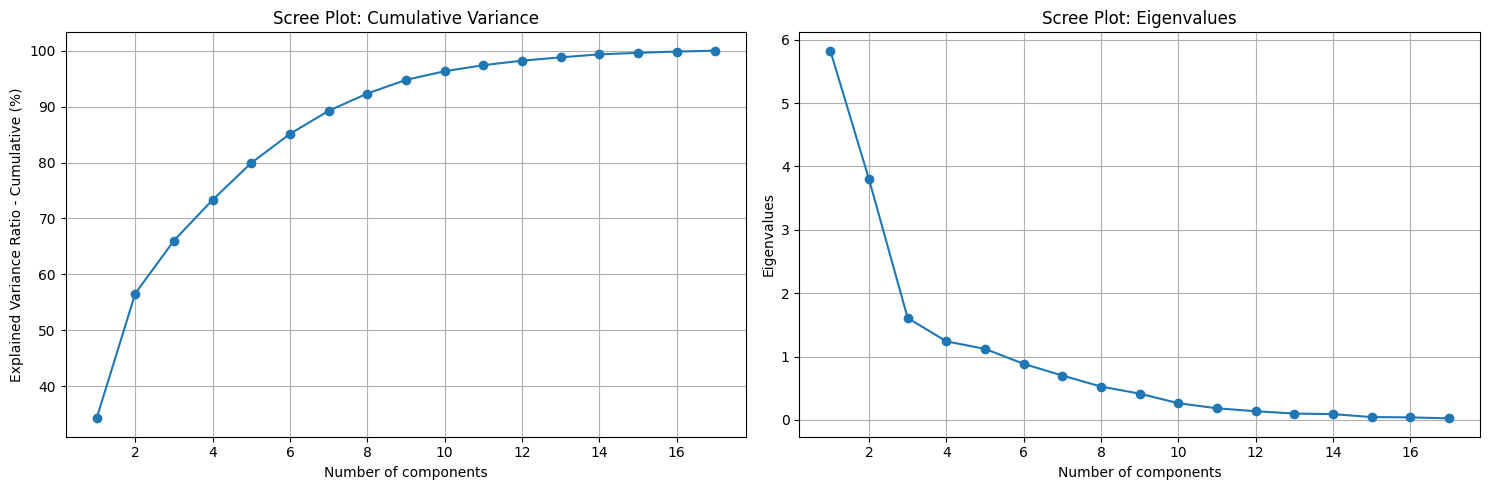

In [146]:
# Hitung jumlah komponen yang ada secara dinamis
n_components = len(df_pca.explained_variance_ratio_)
x_axis = range(1, n_components + 1)

# Plot the Cumulative of Explained Variance Ratio
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(x_axis, np.cumsum(df_pca.explained_variance_ratio_ * 100), marker='o') # Menambahkan marker agar titik terlihat
plt.xlabel('Number of components')
plt.ylabel('Explained Variance Ratio - Cumulative (%)')
plt.title('Scree Plot: Cumulative Variance')

# Plot the Eigenvalues
plt.subplot(1, 2, 2)
plt.grid()
plt.plot(x_axis, df_pca.explained_variance_, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Eigenvalues')
plt.title('Scree Plot: Eigenvalues')

plt.tight_layout()  
plt.show()


#### Insight :

Berdasarkan tahap awal pengujian, dilakukan reduksi dimensi menggunakan PCA di mana akumulasi rasio varians menunjukkan bahwa penggunaan 6 komponen utama berhasil mempertahankan lebih dari 80% informasi dataset asli. Hal ini diperkuat oleh Scree Plot Eigenvalues yang menunjukkan terdapat 5 komponen dengan nilai di atas 1 (Kriteria Kaiser), yang berarti komponen-komponen tersebut sangat signifikan dalam menjelaskan pola data pelanggan.

In [147]:
# untuk variance ratio saya memilih 85 % dari informasi
#general: 90-95%
cumsum = np.cumsum(df_pca.explained_variance_ratio_)
num_features = np.argmax(cumsum >= 0.85) + 1
num_features

6

## vii. Model Definition

### Transformasi Data dengan PCA (5 Komponen)
Titik Tengah Terbaik. Informasi cukup detail tapi dimensi tetap rendah, dengan eigen variance ratio cummulative 85% ada 6 komponen sedangkan eigenvalue >1 ada 5 

In [148]:
# train mode dengan mengurangi jadi 5 komponen
# Definisi PCA dengan 5 komponen sesuai hasil analisa tadi

pca_final = PCA(n_components=5, random_state=42)
data_pca = pca_final.fit_transform(df_scaled) # Gunakan data yang sudah di-scaling & log-transform


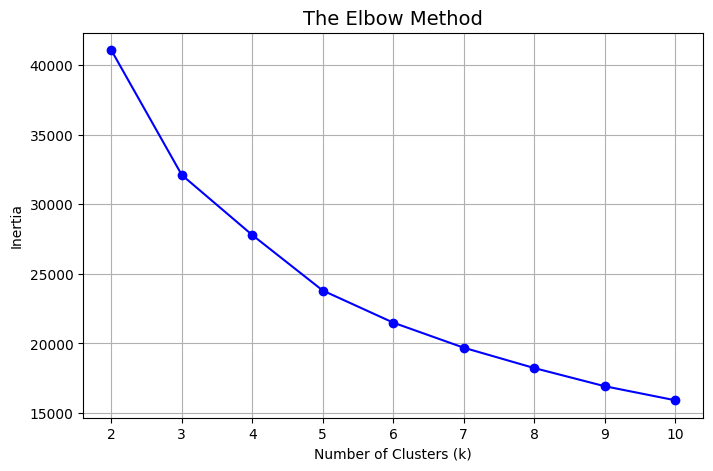

In [149]:
k_inertia = []
K_range = range(2, 11)

for i in K_range:
    # Menggunakan data_pca (hasil 5 komponen)
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(data_pca) 
    k_inertia.append(km.inertia_)

# Visualisasi Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, k_inertia, marker="o", color='blue')
plt.title('The Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


Menghitung Silhouette Score...
Silhouette Score untuk k=2: 0.3169
Silhouette Score untuk k=3: 0.2898
Silhouette Score untuk k=4: 0.2819
Silhouette Score untuk k=5: 0.2905
Silhouette Score untuk k=6: 0.2899
Silhouette Score untuk k=7: 0.2874
Silhouette Score untuk k=8: 0.2472
Silhouette Score untuk k=9: 0.2554
Silhouette Score untuk k=10: 0.2525


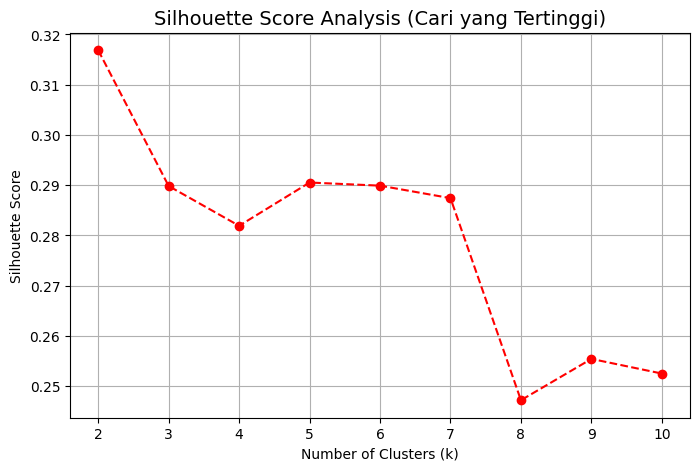

In [150]:
from sklearn.metrics import silhouette_score

# Menyiapkan list untuk menyimpan score
k_silhouette = []
K_range = range(2, 11)

print("Menghitung Silhouette Score...")

for k in K_range:
    # Menggunakan parameter yang sama dengan sel Elbow 
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    
    # Fit & Predict untuk mendapatkan label cluster
    cluster_labels = km.fit_predict(data_pca)
    
    # Hitung Silhouette Score
    score = silhouette_score(data_pca, cluster_labels)
    k_silhouette.append(score)
    print(f"Silhouette Score untuk k={k}: {score:.4f}")

# Visualisasi Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(K_range, k_silhouette, marker="o", color='red', linestyle='--')
plt.title('Silhouette Score Analysis (Cari yang Tertinggi)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


For n_clusters = 2, average silhouette_score is : 0.3169
For n_clusters = 3, average silhouette_score is : 0.2898
For n_clusters = 4, average silhouette_score is : 0.2819
For n_clusters = 5, average silhouette_score is : 0.2905
For n_clusters = 6, average silhouette_score is : 0.2899


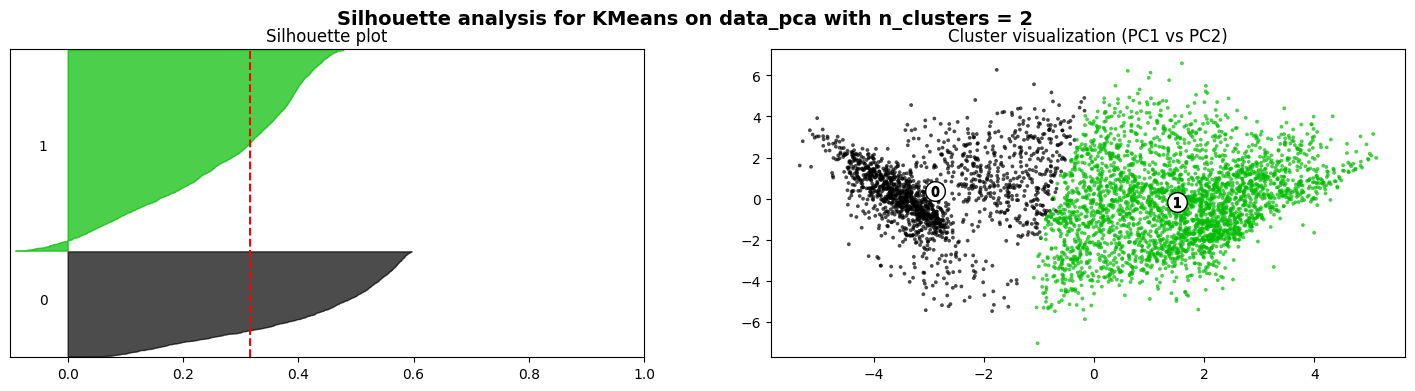

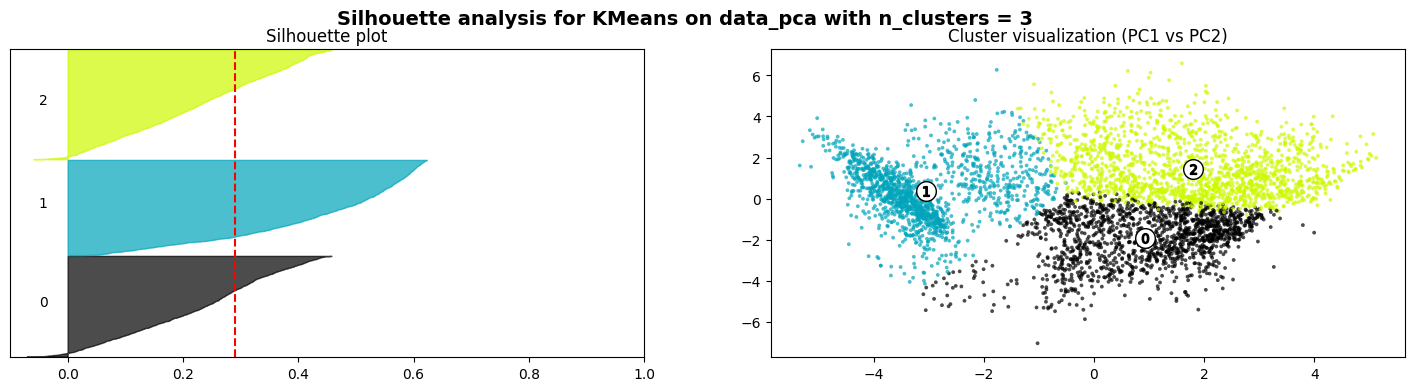

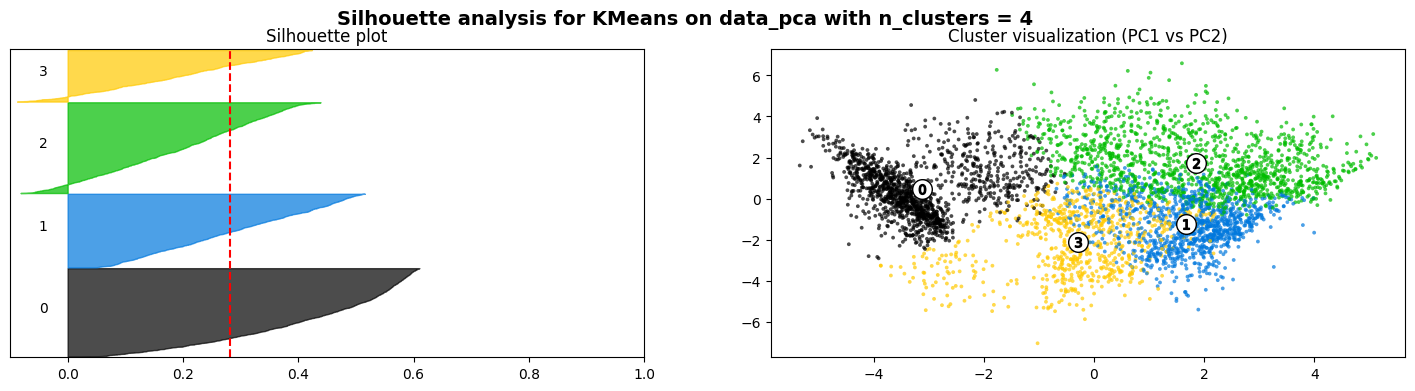

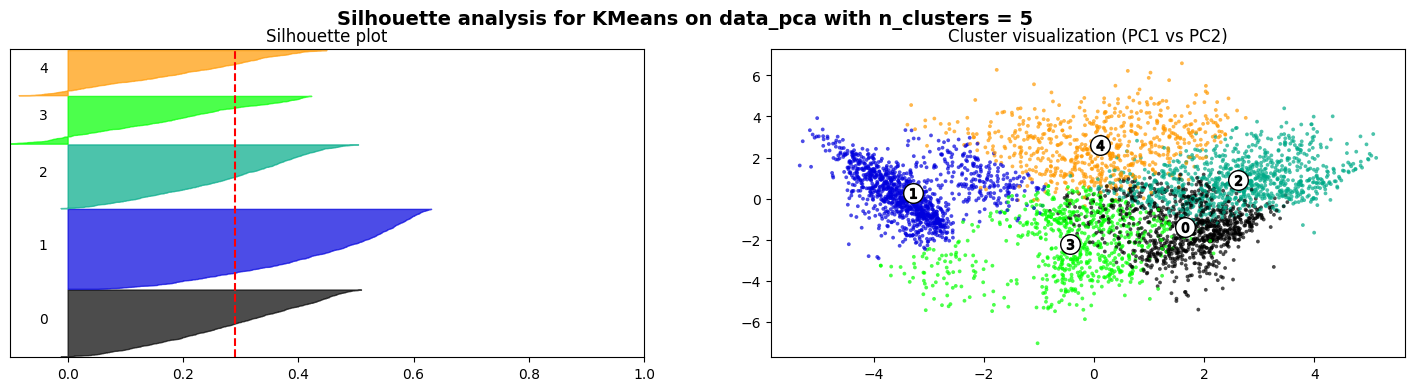

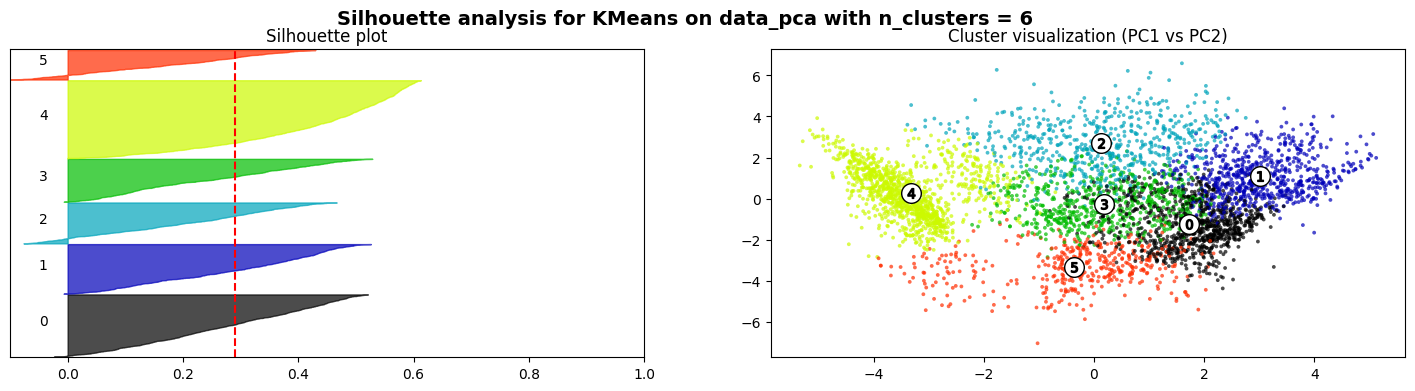

In [151]:
def plot_silhouette(range_n_clusters, X, random_state):
    # Pastikan data dalam bentuk numpy array untuk indexing [:, 0]
    if hasattr(X, 'values'):
        X_vals = X.values
    else:
        X_vals = X

    for n_clusters in range_n_clusters:
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 4)

        ax1.set_xlim([-0.1, 1])
        ax1.set_ylim([0, len(X_vals) + (n_clusters + 1) * 10])

        # Menggunakan random_state=42 sesuai kode Elbow 
        clusterer = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=random_state)
        cluster_labels = clusterer.fit_predict(X_vals)

        silhouette_avg = silhouette_score(X_vals, cluster_labels)
        print(f"For n_clusters = {n_clusters}, average silhouette_score is : {silhouette_avg:.4f}")

        sample_silhouette_values = silhouette_samples(X_vals, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax1.set_title("Silhouette plot")
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])

        # Plot kanan: Visualisasi Cluster (Menggunakan 2 Komponen PCA pertama)
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X_vals[:, 0], X_vals[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')
        
        centers = clusterer.cluster_centers_
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o', c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

        ax2.set_title("Cluster visualization (PC1 vs PC2)")
        plt.suptitle(f"Silhouette analysis for KMeans on data_pca with n_clusters = {n_clusters}", fontsize=14, fontweight='bold')

# 1. Gunakan data_pca dan random_state=42 agar sinkron dengan Elbow
# 2. Coba visualisasikan k dari 2 sampai 6 (atau sesuaikan kebutuhan)
K_range_silhouette = range(2, 7) 

# 3. Jalankan fungsi
plot_silhouette(K_range_silhouette, data_pca, 42)

# 4. Tampilkan semua plot
plt.show()


INSIGHT :

Berdasarkan analisis terintegrasi dari ketiga grafik di atas, jumlah klaster optimal ditetapkan pada k=3. Meskipun secara matematis k=2 memiliki skor Silhouette tertinggi (0.3169), penggunaan k=3 dipilih untuk menghindari segmentasi yang terlalu sederhana (over-simplification) agar tetap bisa menangkap variansi data yang lebih kaya. 
Pilihan ini didasarkan pada keseimbangan terbaik antara efisiensi dan kualitas segmentasi: Melalui Metode Elbow, penurunan Inertia mulai melandai secara signifikan pada titik k=3, menandakan efisiensi variansi yang optimal. Hal ini diperkuat oleh Silhouette Line Plot yang menunjukkan skor rata-rata yang stabil (0.2898), serta Individual Silhouette Plot yang membuktikan bahwa seluruh klaster berhasil melampaui garis rata-rata tanpa adanya data dengan skor negatif (misclassification). Dibandingkan k=2 yang terlalu umum atau k=4 yang mulai menunjukkan ketidakseimbangan ukuran klaster, k=3 memberikan struktur pengelompokan yang paling stabil dan informatif bagi dataset ini

## viii. Model Training

In [157]:
# --- STEP 1: TRAINING (SESUDAH PCA) ---
# Menggunakan k=3 hasil analisis sebelumnya
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
cluster_labels = kmeans_final.fit_predict(data_pca)

# --- STEP 2: MAPPING HASIL ---
# Masukkan label cluster ke DataFrame asli (BUKAN data_pca)
df['Cluster'] = cluster_labels

# --- STEP 3: PROFILING (SEBELUM PCA) ---
# Kita hitung rata-rata tiap fitur asli untuk tiap cluster
profil_cluster = df.groupby('Cluster').mean()

print("Karakteristik Cluster (Data Asli):")
display(profil_cluster)


Karakteristik Cluster (Data Asli):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,238.612465,0.725747,446.547427,160.904320,285.892938,36.416901,0.528875,0.078975,0.433596,0.010247,0.140826,8.268111,3248.111480,695.092715,243.608778,0.248822,11.377116
1,2370.412417,0.918686,89.434202,74.652627,14.820744,2159.640005,0.059995,0.039865,0.019106,0.296567,7.218325,1.004295,4343.071734,1736.091243,1070.962005,0.028841,11.376521
2,2080.854981,0.979978,2314.215884,1453.347826,861.242823,833.158295,0.830968,0.457814,0.600424,0.112276,2.798876,33.224859,5777.545284,2707.599090,1229.420636,0.165177,11.772017


In [153]:
#iterasi keberapa dia konvergen

kmeans_final.n_iter_

10

## ix. Model Evaluation

In [154]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hitung metrik untuk hasil k=3
s_score = silhouette_score(data_pca, cluster_labels)
db_index = davies_bouldin_score(data_pca, cluster_labels)
ch_index = calinski_harabasz_score(data_pca, cluster_labels)

print(f"Silhouette Score: {s_score:.4f} (Makin tinggi makin bagus)")
print(f"Davies-Bouldin Index: {db_index:.4f} (Makin rendah makin bagus)")
print(f"Calinski-Harabasz Index: {ch_index:.4f} (Makin tinggi makin bagus)")


Silhouette Score: 0.2898 (Makin tinggi makin bagus)
Davies-Bouldin Index: 1.3608 (Makin rendah makin bagus)
Calinski-Harabasz Index: 1999.6608 (Makin tinggi makin bagus)


#### Insight :

Berdasarkan pengujian menggunakan tiga metrik internal, model dengan k=3 klaster menunjukkan performa yang paling valid dan stabil untuk digunakan. Meskipun secara matematis k=2 memiliki skor tertinggi, pemilihan k=3 dilakukan untuk menghindari pengelompokan yang terlalu sederhana (over-simplification) agar hasil segmentasi lebih informatif. Nilai Silhouette Score sebesar 0.2898 mengonfirmasi pemisahan antar kelompok yang sudah baik, didukung oleh Davies-Bouldin Index yang rendah (1.3608) sebagai jaminan bahwa pelanggan di dalam satu kelompok memiliki perilaku yang sangat serupa. Selain itu, skor Calinski-Harabasz yang tinggi (1999.66) mempertegas bahwa model berhasil memaksimalkan perbedaan karakteristik antar segmen, sehingga strategi pemasaran yang dirancang untuk satu kelompok tidak akan tumpang tindih dengan kelompok lainnya. Kombinasi ini membuat hasil segmentasi sangat layak dan akurat untuk dasar pengambilan keputusan bisnis yang lebih personal (targeted)

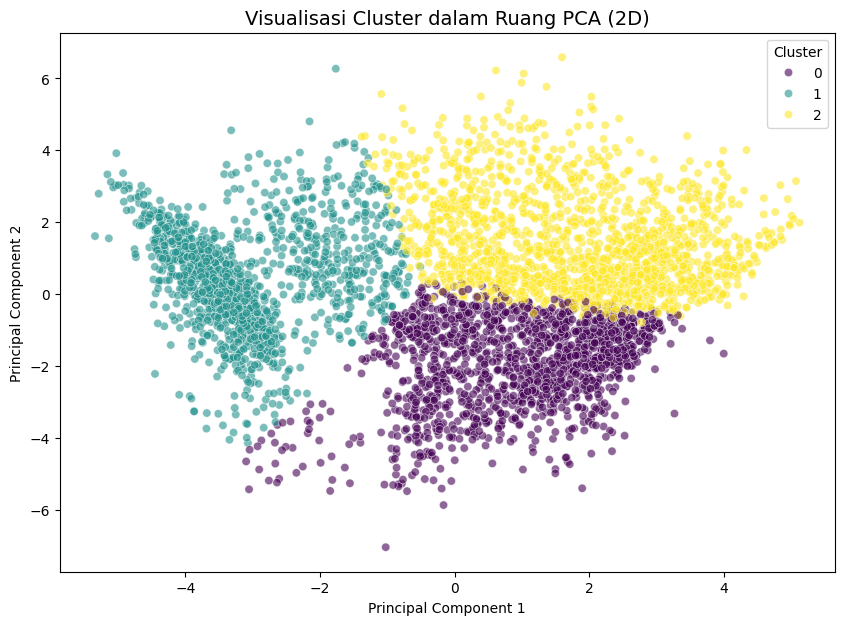

In [155]:
# kita cukup ambil 2 kolom pertama saja untuk scatter plot 2D.

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data_pca[:, 0], 
    y=data_pca[:, 1], 
    hue=cluster_labels, # Menggunakan label hasil training k=3 tadi
    palette='viridis',   # 'seismic' juga bagus, tapi 'viridis' sering lebih jelas
    alpha=0.6
)

plt.title('Visualisasi Cluster dalam Ruang PCA (2D)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


x. Model Saving

In [158]:
import joblib

# 1. Simpan MEDIAN (dari data asli setelah handle missing value, tapi SEBELUM Log/Scale)
medians_data = df.median() 
joblib.dump(medians_data, 'medians_data.pkl')

# 2. Simpan SCALER 
joblib.dump(scaler, 'scaler_model.pkl')

# 3. Simpan PCA (Ini sudah "hafal" cara meringkas data hasil Log + Scale)
joblib.dump(pca_final, 'pca_model.pkl')

# 4. Simpan KMEANS (Model final k=3)
joblib.dump(kmeans_final, 'kmeans_model.pkl')

print("Semua komponen BERHASIL disimpan!")



Semua komponen BERHASIL disimpan!


### xi. Kesimpulan

- Identifikasi Segmen yang Kontras: Melalui pemodelan k=3, pelanggan terbagi secara tegas menjadi tiga profil unik: Klaster 0 sebagai pengguna pasif dengan transaksi terendah, Klaster 1 sebagai pengguna yang berfokus pada penarikan tunai (Cash Advance) dengan saldo tinggi, dan Klaster 2 sebagai pelanggan bernilai tinggi (High-Value) yang paling aktif berbelanja dan memiliki limit kredit terbesar.

- Validitas dan Stabilitas Model: Pemilihan 3 klaster terbukti sangat valid secara statistik dengan skor Calinski-Harabasz yang tinggi (1999.66) dan Davies-Bouldin Index yang rendah (1.3608), yang mengonfirmasi bahwa setiap kelompok memiliki karakteristik yang sangat berbeda satu sama lain namun sangat kompak di dalam kelompoknya sendiri.

- Kapasitas Kredit Bukan Pendorong Transaksi: Hasil uji korelasi Spearman dan scatter plot menunjukkan bahwa besarnya CREDIT_LIMIT memiliki hubungan yang sangat lemah dengan frekuensi pembelian, sehingga strategi untuk meningkatkan transaksi tidak bisa hanya mengandalkan kenaikan limit kredit, melainkan harus lebih personal sesuai profil perilaku di tiap klaster.